# Challenge: K-Nearest Neighbors

En este challenge aplicamos el algoritmo **KNN** a dos problemas reales y
evaluamos su rendimiento de forma rigurosa:

* **Parte A &mdash; Cancer data:** clasificar tumores como **malignos** o
  **benignos** a partir de caracteristicas morfologicas del nucleo celular.
* **Parte B &mdash; Wine Quality:** determinar la calidad de un vino a partir de
  sus propiedades fisicoquimicas.

> Recordatorio: KNN es un algoritmo basado en distancias, por lo que **siempre**
> hay que escalar las variables y elegir cuidadosamente el numero de vecinos `K`.

## Librerias

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, accuracy_score)

RANDOM_STATE = 42

# Parte A &mdash; Cancer data

## Objetivo
Detectar tumores **malignos (M)** y **benignos (B)** con el dataset *Breast Cancer Wisconsin (Diagnostic)*

In [2]:
cancer = pd.read_csv("data.csv")
print("Dimensiones:", cancer.shape)
cancer.head()

Dimensiones: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### Limpieza y exploracion
El dataset trae una columna `id` (identificador, sin valor predictivo) y una columna fantasma `Unnamed: 32` totalmente vacia. Las eliminamos y codificamos la
variable objetivo `diagnosis` como **1 = Maligno** y **0 = Benigno**.

In [3]:
cancer = cancer.drop(columns=["id", "Unnamed: 32"], errors="ignore")
cancer["diagnosis"] = cancer["diagnosis"].map({"M": 1, "B": 0})

print("Valores nulos:", int(cancer.isna().sum().sum()))
print(cancer["diagnosis"].value_counts().rename({0: "Benigno", 1: "Maligno"}))
cancer.describe().T.head()

Valores nulos: 0
diagnosis
Benigno    357
Maligno    212
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.000,0.00,0.00,1.00,1.00
radius_mean,569.0,14.127292,3.524049,6.981,11.70,13.37,15.78,28.11
texture_mean,569.0,19.289649,4.301036,9.710,16.17,18.84,21.80,39.28
perimeter_mean,569.0,91.969033,24.298981,43.790,75.17,86.24,104.10,188.50
area_mean,569.0,654.889104,351.914129,143.500,420.30,551.10,782.70,2501.00


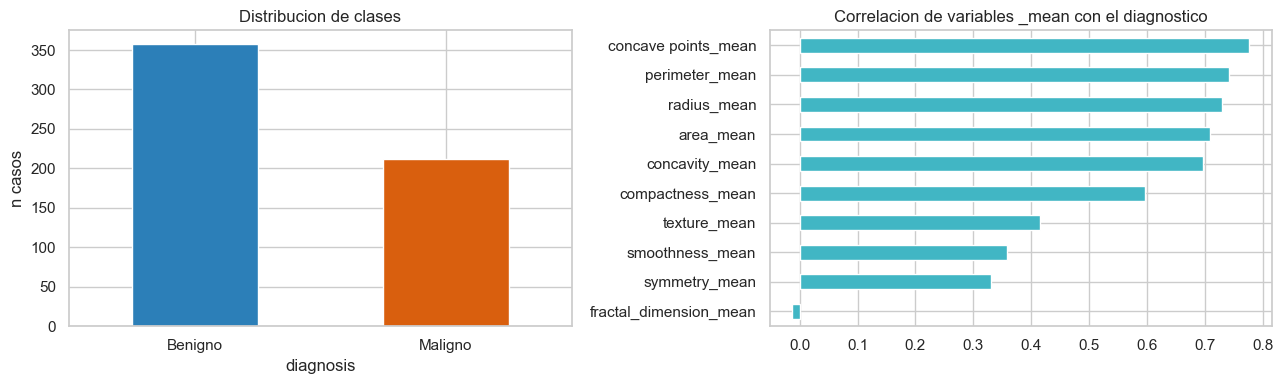

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
cancer["diagnosis"].map({0: "Benigno", 1: "Maligno"}).value_counts().plot(
    kind="bar", color=["#2c7fb8", "#d95f0e"], ax=ax[0])
ax[0].set_title("Distribucion de clases")
ax[0].set_ylabel("n casos"); ax[0].tick_params(axis="x", rotation=0)

# correlacion de las 10 variables '_mean' con el diagnostico
mean_cols = [c for c in cancer.columns if c.endswith("_mean")]
corr = cancer[mean_cols + ["diagnosis"]].corr()["diagnosis"].drop("diagnosis").sort_values()
corr.plot(kind="barh", color="#41b6c4", ax=ax[1])
ax[1].set_title("Correlacion de variables _mean con el diagnostico")
plt.tight_layout(); plt.show()

### Particion y escalado
Separamos 80% entrenamiento / 20% prueba **estratificando** por la clase (para mantener la proporcion M/B) y estandarizamos las variables. El `scaler` se ajusta **solo** con los datos de entrenamiento para evitar fuga de informacion.

In [5]:
X = cancer.drop(columns="diagnosis")
y = cancer["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
print("Train:", X_train_s.shape, " Test:", X_test_s.shape)

Train: (455, 30)  Test: (114, 30)


### Eleccion de K
Un buen punto de partida es `K = sqrt(n)`, pero lo validamos: probamos varias `K` y elegimos la que maximiza la exactitud en validacion cruzada (5 folds) sobre el entrenamiento, evitando asi sobreajustar a un unico conjunto de prueba.

sqrt(n) ~ 21  |  Mejor K (CV): 3  (accuracy CV=0.969)


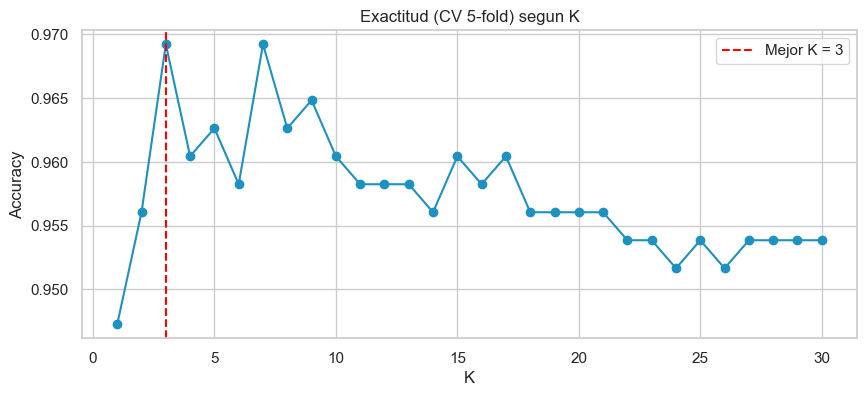

In [6]:
ks = range(1, 31)
cv_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k),
                             X_train_s, y_train, cv=5, scoring="accuracy").mean()
             for k in ks]
mejor_k = ks[int(np.argmax(cv_scores))]
print(f"sqrt(n) ~ {np.sqrt(len(X_train_s)):.0f}  |  Mejor K (CV): {mejor_k}"
      f"  (accuracy CV={max(cv_scores):.3f})")

plt.figure(figsize=(10, 4))
plt.plot(ks, cv_scores, "-o", color="#1d91c0")
plt.axvline(mejor_k, color="red", linestyle="--", label=f"Mejor K = {mejor_k}")
plt.title("Exactitud (CV 5-fold) segun K"); plt.xlabel("K"); plt.ylabel("Accuracy")
plt.legend(); plt.show()

### Evaluacion del modelo final

Accuracy test : 0.939
ROC AUC test  : 0.982

              precision    recall  f1-score   support

     Benigno       0.92      0.99      0.95        72
     Maligno       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



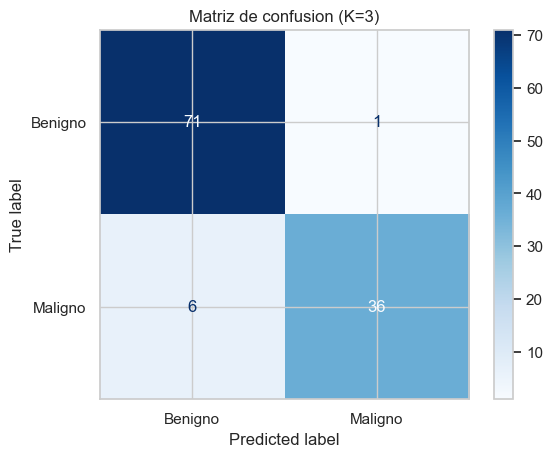

In [7]:
knn = KNeighborsClassifier(n_neighbors=mejor_k)
knn.fit(X_train_s, y_train)
y_pred = knn.predict(X_test_s)
y_proba = knn.predict_proba(X_test_s)[:, 1]

print(f"Accuracy test : {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC AUC test  : {roc_auc_score(y_test, y_proba):.3f}\n")
print(classification_report(y_test, y_pred, target_names=["Benigno", "Maligno"]))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=["Benigno", "Maligno"]).plot(cmap="Blues")
plt.title(f"Matriz de confusion (K={mejor_k})"); plt.show()

### Conclusiones &mdash; Parte A
* Con escalado y una `K` validada por CV, KNN alcanza una exactitud y un **ROC AUC** muy altos (> 0.95) en la deteccion de tumores.
* En un contexto medico interesa minimizar los **falsos negativos** (un tumor maligno clasificado como benigno): conviene vigilar el *recall* de la clase *Maligno* en la matriz de confusion.

# Parte B &mdash; Wine Quality

## Objetivo
Determinar la calidad del vino a partir de sus caracteristicas fisicoquimicas
([UCI Wine Quality](https://archive.ics.uci.edu/ml/datasets/Wine+Quality)).
Usamos los conjuntos de vino **tinto** y **blanco**.

In [8]:
red = pd.read_csv("winequality-red.csv", sep=";").assign(wine_type="red")
white = pd.read_csv("winequality-white.csv", sep=";").assign(wine_type="white")
wine = pd.concat([red, white], ignore_index=True)
print("Dimensiones:", wine.shape)
wine.head()

Dimensiones: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


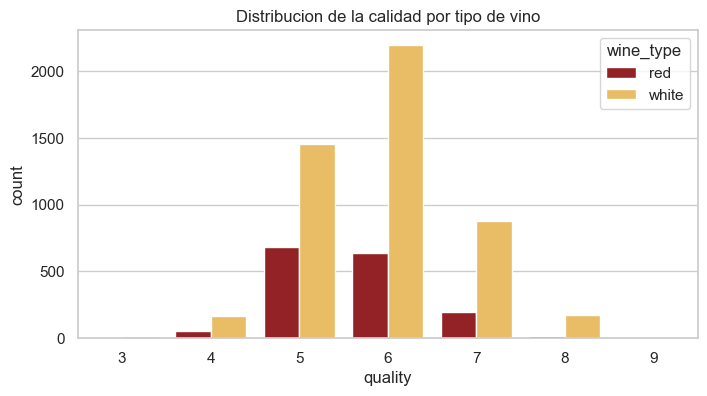

count    6497.000000
mean        5.818378
std         0.873255
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         9.000000
Name: quality, dtype: float64


In [9]:
plt.figure(figsize=(8, 4))
sns.countplot(data=wine, x="quality", hue="wine_type",
              palette={"red": "#a50f15", "white": "#fec44f"})
plt.title("Distribucion de la calidad por tipo de vino"); plt.show()
print(wine["quality"].describe())

### Ingenieria de la variable objetivo
La calidad va de 3 a 9 y esta muy desbalanceada (dominan 5 y 6). Clasificarla como 7 clases con KNN es poco fiable, asi que la convertimos en un problema **binario** mas util para negocio: vino **bueno** (`quality >= 7`) vs. **no bueno**. Tambien codificamos el tipo de vino como variable numerica.

In [10]:
wine["good"] = (wine["quality"] >= 7).astype(int)
wine["wine_type"] = wine["wine_type"].map({"red": 0, "white": 1})

Xw = wine.drop(columns=["quality", "good"])
yw = wine["good"]
print(yw.value_counts(normalize=True).rename({0: "No bueno", 1: "Bueno"}).round(3))

good
No bueno    0.803
Bueno       0.197
Name: proportion, dtype: float64


In [11]:
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    Xw, yw, test_size=0.20, random_state=RANDOM_STATE, stratify=yw)

scaler_w = StandardScaler().fit(Xw_train)
Xw_train_s = scaler_w.transform(Xw_train)
Xw_test_s = scaler_w.transform(Xw_test)

### Eleccion de K y evaluacion

Mejor K (CV, F1): 1  (F1 CV=0.609)


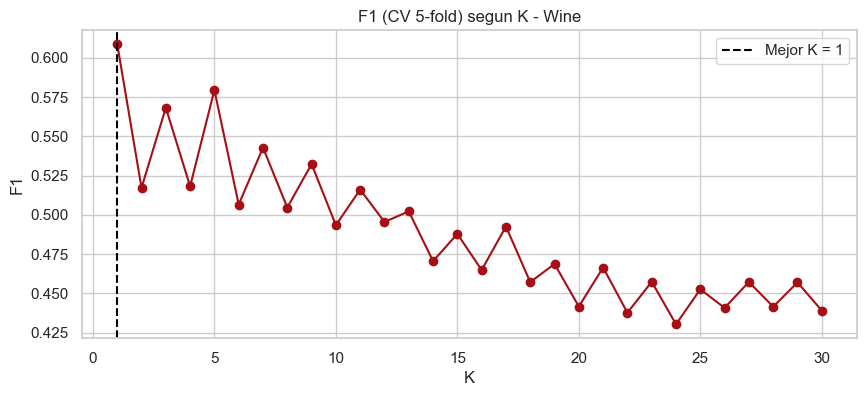

In [12]:
ks = range(1, 31)
cv_scores_w = [cross_val_score(KNeighborsClassifier(n_neighbors=k),
                               Xw_train_s, yw_train, cv=5,
                               scoring="f1").mean() for k in ks]
mejor_k_w = ks[int(np.argmax(cv_scores_w))]
print(f"Mejor K (CV, F1): {mejor_k_w}  (F1 CV={max(cv_scores_w):.3f})")

plt.figure(figsize=(10, 4))
plt.plot(ks, cv_scores_w, "-o", color="#a50f15")
plt.axvline(mejor_k_w, color="black", linestyle="--", label=f"Mejor K = {mejor_k_w}")
plt.title("F1 (CV 5-fold) segun K - Wine"); plt.xlabel("K"); plt.ylabel("F1")
plt.legend(); plt.show()

Accuracy test : 0.860

              precision    recall  f1-score   support

    No bueno       0.91      0.92      0.91      1044
       Bueno       0.65      0.62      0.64       256

    accuracy                           0.86      1300
   macro avg       0.78      0.77      0.78      1300
weighted avg       0.86      0.86      0.86      1300



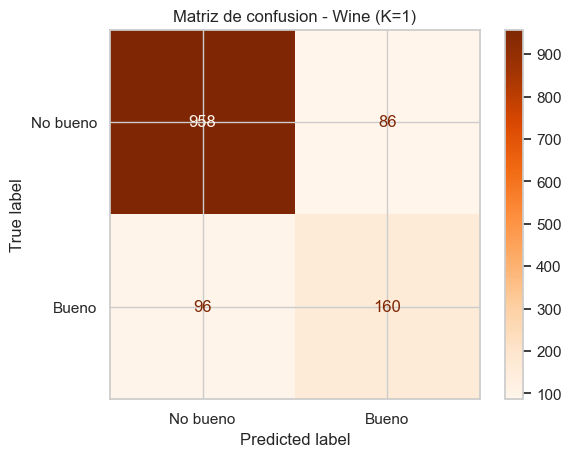

In [13]:
knn_w = KNeighborsClassifier(n_neighbors=mejor_k_w)
knn_w.fit(Xw_train_s, yw_train)
yw_pred = knn_w.predict(Xw_test_s)

print(f"Accuracy test : {accuracy_score(yw_test, yw_pred):.3f}\n")
print(classification_report(yw_test, yw_pred, target_names=["No bueno", "Bueno"]))

ConfusionMatrixDisplay(confusion_matrix(yw_test, yw_pred),
                       display_labels=["No bueno", "Bueno"]).plot(cmap="Oranges")
plt.title(f"Matriz de confusion - Wine (K={mejor_k_w})"); plt.show()

### Conclusiones &mdash; Parte B
* El problema del vino es **mas dificil** que el del cancer: las clases se solapan y existe **desbalance** (los vinos "buenos" son minoria), por lo que usamos **F1** en lugar de accuracy para elegir `K`.
* KNN logra una exactitud razonable pero su *recall* sobre la clase minoritaria es limitado.


